<a href="https://colab.research.google.com/github/sivasakthi-15/SCT_DS_TASKS/blob/main/SCT_DS_TASKS_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

df=pd.read_csv("/content/drive/MyDrive/SCT TASKS/bank-full.csv",delimiter=';')
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [13]:
print(df.head())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


In [14]:
print(df.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [15]:
print(df.isnull())

         age    job  marital  education  default  balance  housing   loan  \
0      False  False    False      False    False    False    False  False   
1      False  False    False      False    False    False    False  False   
2      False  False    False      False    False    False    False  False   
3      False  False    False      False    False    False    False  False   
4      False  False    False      False    False    False    False  False   
...      ...    ...      ...        ...      ...      ...      ...    ...   
45206  False  False    False      False    False    False    False  False   
45207  False  False    False      False    False    False    False  False   
45208  False  False    False      False    False    False    False  False   
45209  False  False    False      False    False    False    False  False   
45210  False  False    False      False    False    False    False  False   

       contact    day  month  duration  campaign  pdays  previous  poutcome

In [16]:
print(df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')


In [17]:
label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

In [18]:
df.rename(columns=lambda x: x.strip(), inplace=True)
X = df.drop(columns=['y'])
y = df['y']

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [20]:
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_rep)

Accuracy: 0.8740
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93      7952
           1       0.48      0.48      0.48      1091

    accuracy                           0.87      9043
   macro avg       0.70      0.70      0.70      9043
weighted avg       0.87      0.87      0.87      9043



In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
dt_bal = DecisionTreeClassifier(random_state=42, class_weight='balanced')
lr_bal = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
rf_bal = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=200)

dt_bal.fit(X_train, y_train)
lr_bal.fit(X_train_scaled, y_train)
rf_bal.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [23]:
results = {}

def evaluate(name, model, X_te):
    preds = model.predict(X_te)
    probs = model.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_test, probs)
    results[name] = auc
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    print(f"ROC-AUC: {auc:.4f}")
    print(classification_report(y_test, preds))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, preds))

evaluate("Decision Tree (balanced)", dt_bal, X_test)
evaluate("Logistic Regression (balanced)", lr_bal, X_test_scaled)
evaluate("Random Forest (balanced)", rf_bal, X_test)


Decision Tree (balanced)
ROC-AUC: 0.6786
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      7952
           1       0.46      0.43      0.44      1091

    accuracy                           0.87      9043
   macro avg       0.69      0.68      0.68      9043
weighted avg       0.87      0.87      0.87      9043

Confusion Matrix:
[[7410  542]
 [ 627  464]]

Logistic Regression (balanced)
ROC-AUC: 0.8739
              precision    recall  f1-score   support

           0       0.97      0.80      0.88      7952
           1       0.36      0.81      0.50      1091

    accuracy                           0.80      9043
   macro avg       0.66      0.81      0.69      9043
weighted avg       0.89      0.80      0.83      9043

Confusion Matrix:
[[6391 1561]
 [ 210  881]]

Random Forest (balanced)
ROC-AUC: 0.9251
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7952
           1   

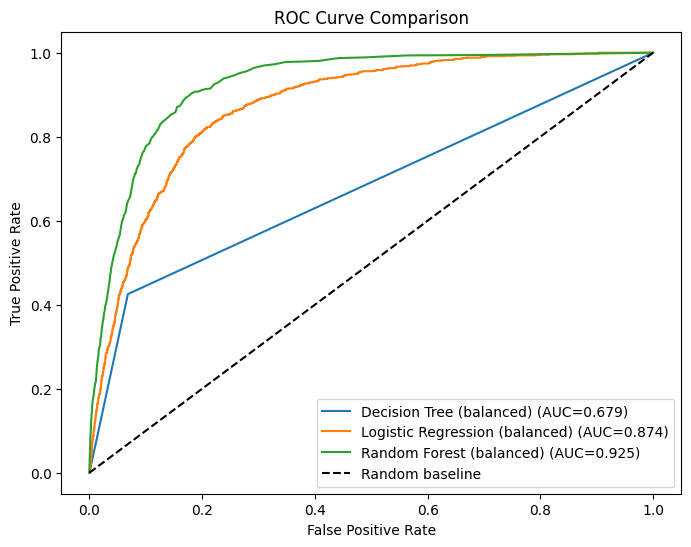

In [26]:
plt.figure(figsize=(8,6))
for name, model, X_te in [
    ("Decision Tree (balanced)", dt_bal, X_test),
    ("Logistic Regression (balanced)", lr_bal, X_test_scaled),
    ("Random Forest (balanced)", rf_bal, X_test)
]:
    probs = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC={results[name]:.3f})")

plt.plot([0,1],[0,1],'k--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.savefig('roc_comparison.png')
plt.show()

In [24]:
comparison_df = pd.DataFrame(list(results.items()), columns=['Model', 'ROC-AUC'])
comparison_df = comparison_df.sort_values('ROC-AUC', ascending=False)
print(comparison_df)

best_model_name = comparison_df.iloc[0]['Model']
best_auc = comparison_df.iloc[0]['ROC-AUC']
print(f"\nBest model: {best_model_name} (ROC-AUC: {best_auc:.4f})")

                            Model   ROC-AUC
2        Random Forest (balanced)  0.925097
1  Logistic Regression (balanced)  0.873948
0        Decision Tree (balanced)  0.678569

Best model: Random Forest (balanced) (ROC-AUC: 0.9251)


In [27]:
print(y.value_counts())
print(label_encoders['y'].classes_)

y
0    39922
1     5289
Name: count, dtype: int64
['no' 'yes']


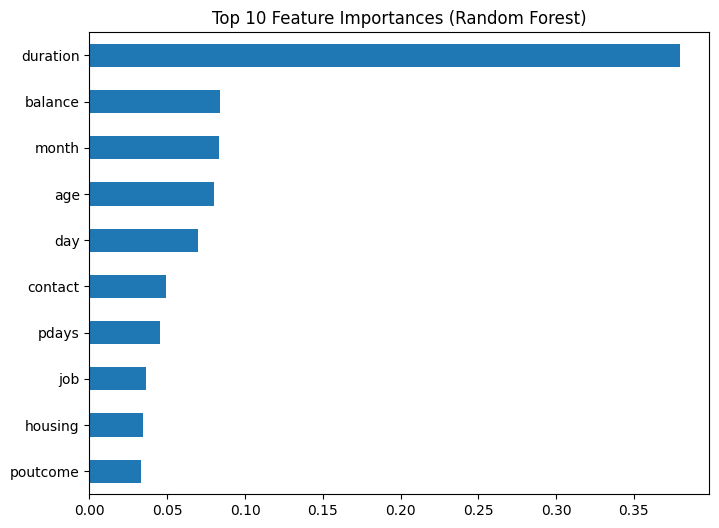

duration    0.379619
balance     0.084182
month       0.083573
age         0.079854
day         0.069624
contact     0.048922
pdays       0.045556
job         0.036373
housing     0.034625
poutcome    0.033264
dtype: float64


In [28]:
importances = pd.Series(rf_bal.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,6))
importances.head(10).plot(kind='barh')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.savefig('feature_importance.png')
plt.show()
print(importances.head(10))

In [29]:
X_no_leak = X.drop(columns=['duration'])

X_train_nl, X_test_nl, y_train_nl, y_test_nl = train_test_split(
    X_no_leak, y, test_size=0.2, random_state=42
)

# Scale for Logistic Regression
scaler_nl = StandardScaler()
X_train_nl_scaled = scaler_nl.fit_transform(X_train_nl)
X_test_nl_scaled = scaler_nl.transform(X_test_nl)

# ===== NEW CELL: Retrain all 3 models WITHOUT duration =====
dt_nl = DecisionTreeClassifier(random_state=42, class_weight='balanced')
lr_nl = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
rf_nl = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=200)

dt_nl.fit(X_train_nl, y_train_nl)
lr_nl.fit(X_train_nl_scaled, y_train_nl)
rf_nl.fit(X_train_nl, y_train_nl)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [30]:
results_no_leak = {}

def evaluate_nl(name, model, X_te, y_te):
    preds = model.predict(X_te)
    probs = model.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_te, probs)
    results_no_leak[name] = auc
    print(f"\n{'='*50}\n{name} (no duration)\n{'='*50}")
    print(f"ROC-AUC: {auc:.4f}")
    print(classification_report(y_te, preds))

evaluate_nl("Decision Tree (no duration)", dt_nl, X_test_nl, y_test_nl)
evaluate_nl("Logistic Regression (no duration)", lr_nl, X_test_nl_scaled, y_test_nl)
evaluate_nl("Random Forest (no duration)", rf_nl, X_test_nl, y_test_nl)

# ===== NEW CELL: Before vs After comparison table =====
before_after = pd.DataFrame({
    'Model': ['Decision Tree', 'Logistic Regression', 'Random Forest'],
    'ROC-AUC (with duration)': [
        results['Decision Tree (balanced)'],
        results['Logistic Regression (balanced)'],
        results['Random Forest (balanced)']
    ],
    'ROC-AUC (without duration)': [
        results_no_leak['Decision Tree (no duration)'],
        results_no_leak['Logistic Regression (no duration)'],
        results_no_leak['Random Forest (no duration)']
    ]
})
before_after['Drop'] = before_after['ROC-AUC (with duration)'] - before_after['ROC-AUC (without duration)']
print(before_after)


Decision Tree (no duration) (no duration)
ROC-AUC: 0.5989
              precision    recall  f1-score   support

           0       0.90      0.91      0.91      7952
           1       0.31      0.28      0.30      1091

    accuracy                           0.84      9043
   macro avg       0.61      0.60      0.60      9043
weighted avg       0.83      0.84      0.83      9043


Logistic Regression (no duration) (no duration)
ROC-AUC: 0.7203
              precision    recall  f1-score   support

           0       0.94      0.63      0.76      7952
           1       0.20      0.69      0.32      1091

    accuracy                           0.64      9043
   macro avg       0.57      0.66      0.54      9043
weighted avg       0.85      0.64      0.70      9043


Random Forest (no duration) (no duration)
ROC-AUC: 0.7836
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7952
           1       0.71      0.19      0.31      1091


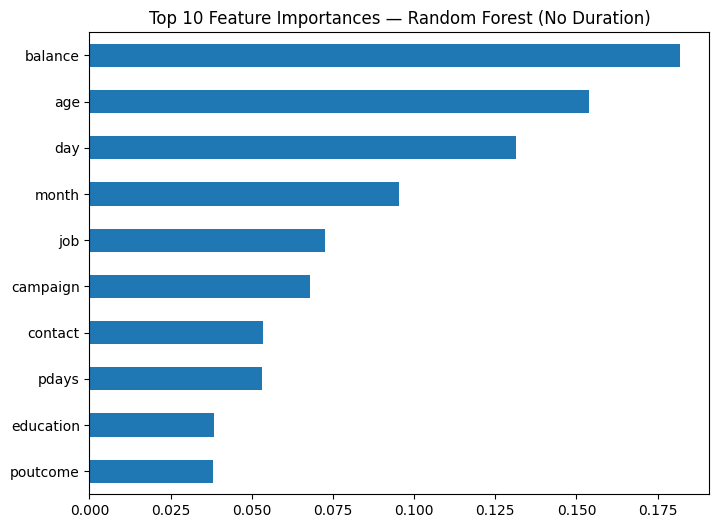

balance      0.181870
age          0.153938
day          0.131449
month        0.095403
job          0.072470
campaign     0.068019
contact      0.053323
pdays        0.053096
education    0.038443
poutcome     0.038183
dtype: float64


In [31]:
importances_nl = pd.Series(rf_nl.feature_importances_, index=X_no_leak.columns).sort_values(ascending=False)
plt.figure(figsize=(8,6))
importances_nl.head(10).plot(kind='barh')
plt.title('Top 10 Feature Importances — Random Forest (No Duration)')
plt.gca().invert_yaxis()
plt.savefig('feature_importance_no_leak.png')
plt.show()
print(importances_nl.head(10))